# Task 3: Heart Disease Prediction


**Objective:** Build a classification model to predict whether a person is at risk of heart disease based on health data.

**Dataset:** Heart Disease UCI Dataset (loaded directly from UCI ML Repository)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_curve, auc, roc_auc_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load the Heart Disease Dataset

In [10]:
# Load Heart Disease UCI dataset directly from URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

col_names = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
             "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]

df = pd.read_csv(url, names=col_names, na_values="?")

print(f"Dataset loaded! Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print()
print("First 5 rows:")
df.head()

Dataset loaded! Shape: (303, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Step 3: Data Cleaning & Preprocessing

### Column Descriptions:
- `age`: Age of the patient
- `sex`: 1 = Male, 0 = Female
- `cp`: Chest pain type (0–3)
- `trestbps`: Resting blood pressure
- `chol`: Serum cholesterol
- `fbs`: Fasting blood sugar > 120 mg/dl
- `restecg`: Resting ECG results
- `thalach`: Maximum heart rate achieved
- `exang`: Exercise induced angina
- `oldpeak`: ST depression
- `slope`: Slope of peak exercise ST segment
- `ca`: Number of major vessels
- `thal`: Thalassemia type
- `target`: 0 = No disease, 1–4 = Disease present

In [11]:
print("=== Missing Values ===")
print(df.isnull().sum())
print()

# Fill missing values with median
df["ca"].fillna(df["ca"].median(), inplace=True)
df["thal"].fillna(df["thal"].median(), inplace=True)

# Binarize target: 0 = no disease, 1 = disease
df["target"] = (df["target"] > 0).astype(int)

print("After cleaning:")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Target distribution:")
print(df["target"].value_counts().to_string())
print()
print("Dataset info:")
df.info()

=== Missing Values ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

After cleaning:
  Missing values: 0
  Target distribution:
target
0    164
1    139

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      30

## Step 4: Exploratory Data Analysis (EDA)

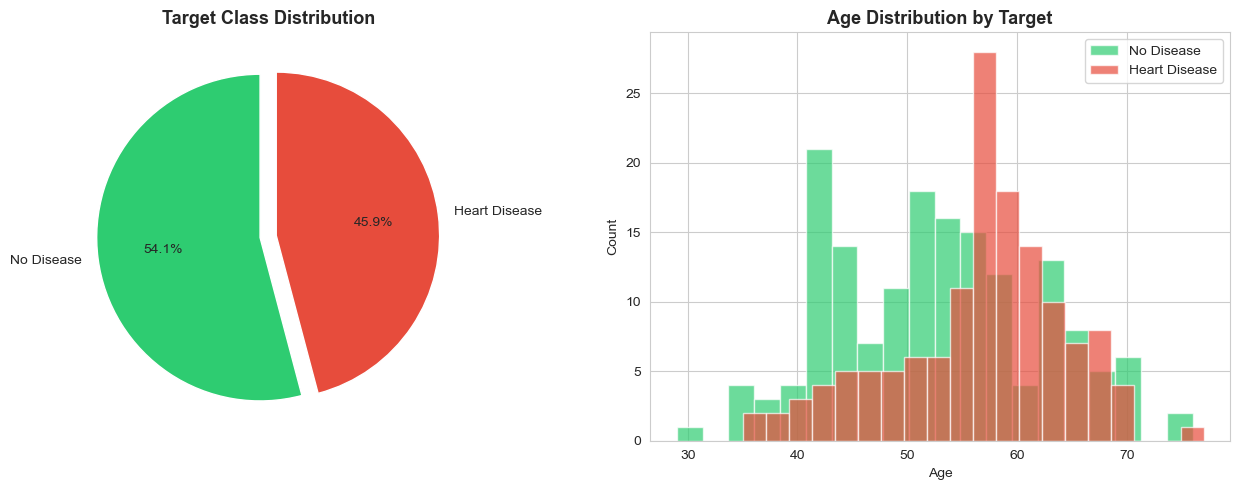

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Target distribution
target_counts = df["target"].value_counts()
axes[0].pie(target_counts, labels=["No Disease", "Heart Disease"],
            autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"], startangle=90,
            explode=(0.05, 0.05))
axes[0].set_title("Target Class Distribution", fontsize=13, fontweight="bold")

# Age distribution by target
df[df["target"]==0]["age"].hist(ax=axes[1], bins=20, alpha=0.7,
                                 color="#2ecc71", label="No Disease")
df[df["target"]==1]["age"].hist(ax=axes[1], bins=20, alpha=0.7,
                                 color="#e74c3c", label="Heart Disease")
axes[1].set_title("Age Distribution by Target", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=100, bbox_inches="tight")
plt.show()

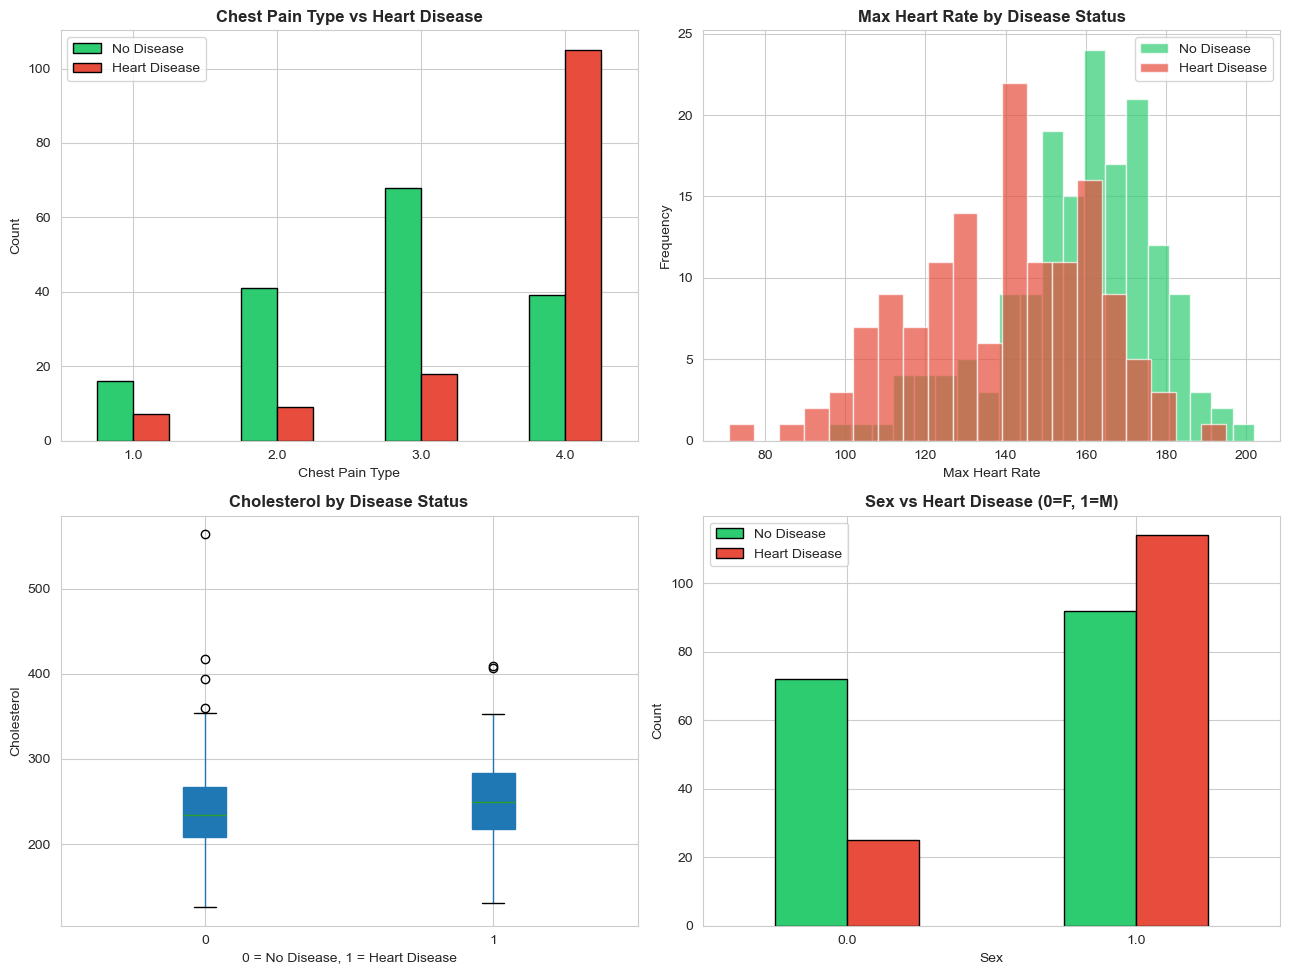

✅ EDA Visualization Completed & Saved as 'eda_features.png'


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()   


#  4. Chest Pain Type vs Target

cp_target = df.groupby(["cp", "target"]).size().unstack()

cp_target.plot(
    kind="bar",
    ax=axes[0],
    color=["#2ecc71", "#e74c3c"],
    edgecolor="black",
    rot=0
)

axes[0].set_title("Chest Pain Type vs Heart Disease", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Chest Pain Type")
axes[0].set_ylabel("Count")
axes[0].legend(["No Disease", "Heart Disease"])

#  5. Max Heart Rate Distribution

df[df["target"] == 0]["thalach"].hist(
    ax=axes[1],
    bins=20,
    alpha=0.7,
    color="#2ecc71",
    label="No Disease"
)

df[df["target"] == 1]["thalach"].hist(
    ax=axes[1],
    bins=20,
    alpha=0.7,
    color="#e74c3c",
    label="Heart Disease"
)

axes[1].set_title("Max Heart Rate by Disease Status", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Max Heart Rate")
axes[1].set_ylabel("Frequency")
axes[1].legend()

#  6. Cholesterol Box Plot

df.boxplot(
    column="chol",
    by="target",
    ax=axes[2],
    patch_artist=True
)

axes[2].set_title("Cholesterol by Disease Status", fontsize=12, fontweight="bold")
axes[2].set_xlabel("0 = No Disease, 1 = Heart Disease")
axes[2].set_ylabel("Cholesterol")

# Remove automatic title from pandas
plt.suptitle("")

# ==========================================
# 📌 7. Sex vs Target
# ==========================================
sex_target = df.groupby(["sex", "target"]).size().unstack()

sex_target.plot(
    kind="bar",
    ax=axes[3],
    color=["#2ecc71", "#e74c3c"],
    edgecolor="black",
    rot=0
)

axes[3].set_title("Sex vs Heart Disease (0=F, 1=M)", fontsize=12, fontweight="bold")
axes[3].set_xlabel("Sex")
axes[3].set_ylabel("Count")
axes[3].legend(["No Disease", "Heart Disease"])

# ==========================================
# 📌 8. Layout + Save
# ==========================================
plt.tight_layout()

plt.savefig(
    "eda_features.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

print("✅ EDA Visualization Completed & Saved as 'eda_features.png'")

### Correlation Heatmap

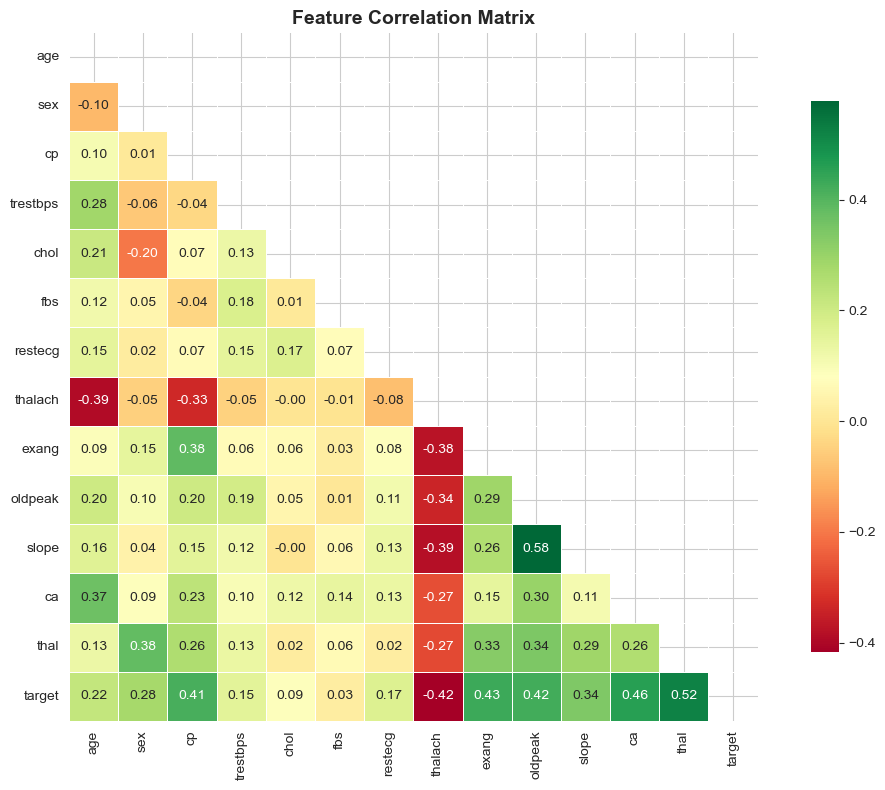

In [14]:
plt.figure(figsize=(11, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            mask=mask, linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=100, bbox_inches="tight")
plt.show()

## Step 5: Feature Selection & Train/Test Split

In [15]:
feature_cols = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
                "thalach", "exang", "oldpeak", "slope", "ca", "thal"]

X = df[feature_cols]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Train class balance: {dict(y_train.value_counts())}")
print(f"Test  class balance: {dict(y_test.value_counts())}")

Training samples : 242
Testing  samples : 61
Train class balance: {0: np.int64(131), 1: np.int64(111)}
Test  class balance: {0: np.int64(33), 1: np.int64(28)}


## Step 6: Train Classification Models

In [16]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

# Model 2: Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_train)
dt_preds = dt.predict(X_test_scaled)
dt_proba = dt.predict_proba(X_test_scaled)[:, 1]

print("Models trained!")
print()
print("LOGISTIC REGRESSION:")
print(f"  Accuracy: {accuracy_score(y_test, lr_preds)*100:.2f}%")
print(f"  AUC-ROC:  {roc_auc_score(y_test, lr_proba):.4f}")

print()
print("DECISION TREE:")
print(f"  Accuracy: {accuracy_score(y_test, dt_preds)*100:.2f}%")
print(f"  AUC-ROC:  {roc_auc_score(y_test, dt_proba):.4f}")

Models trained!

LOGISTIC REGRESSION:
  Accuracy: 86.89%
  AUC-ROC:  0.9513

DECISION TREE:
  Accuracy: 77.05%
  AUC-ROC:  0.8030


## Step 7: Evaluation — Confusion Matrix, ROC Curve & Classification Report

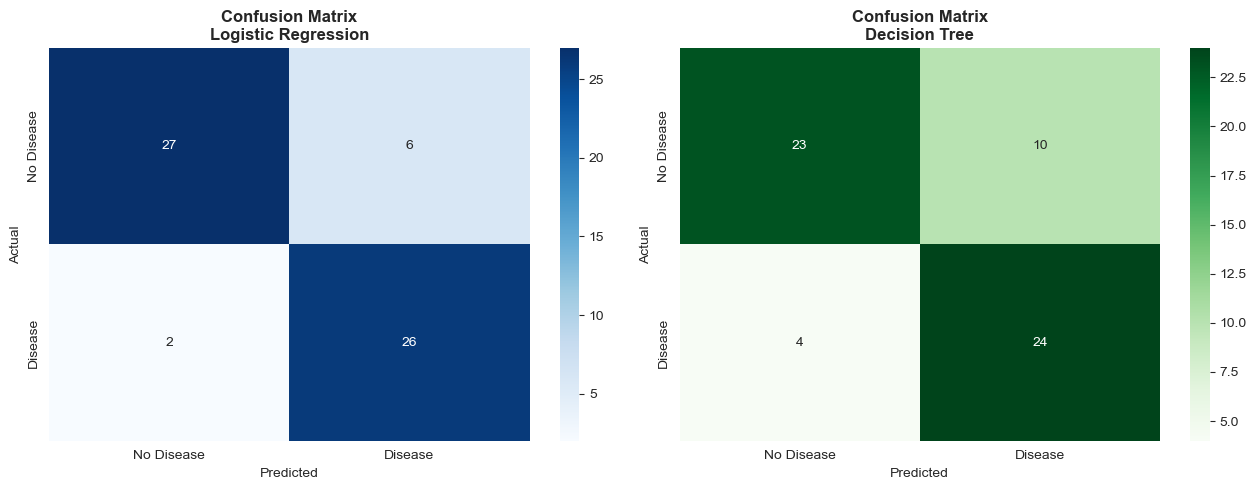

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, name, color in [
    (axes[0], lr_preds, "Logistic Regression", "Blues"),
    (axes[1], dt_preds, "Decision Tree",       "Greens")
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap=color, ax=ax,
                xticklabels=["No Disease", "Disease"],
                yticklabels=["No Disease", "Disease"])
    ax.set_title(f"Confusion Matrix\n{name}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=100, bbox_inches="tight")
plt.show()

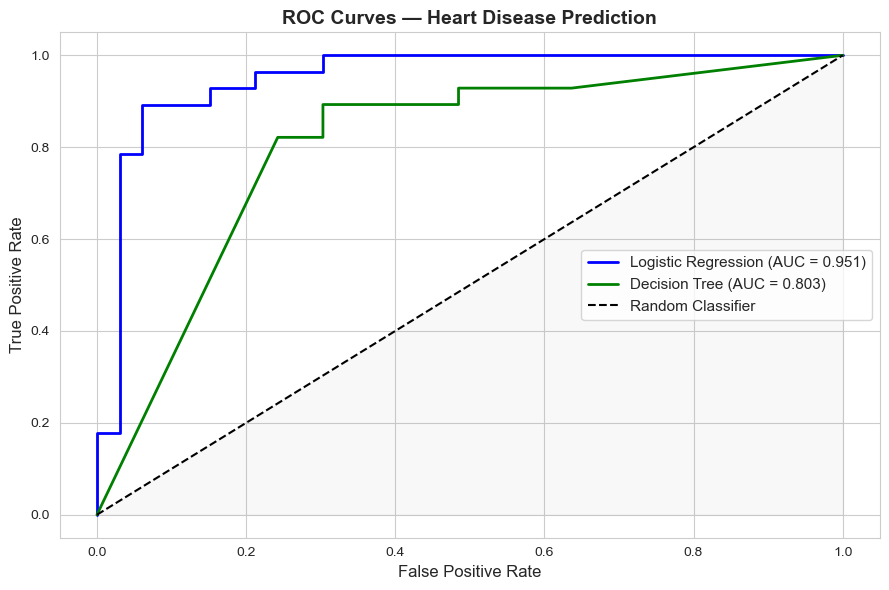

In [18]:
# ROC Curves
plt.figure(figsize=(9, 6))

for proba, name, color in [
    (lr_proba, "Logistic Regression", "blue"),
    (dt_proba, "Decision Tree",       "green")
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score   = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0,1], [0,1], "k--", linewidth=1.5, label="Random Classifier")
plt.fill_between([0,1], [0,1], alpha=0.05, color="gray")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — Heart Disease Prediction", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=100, bbox_inches="tight")
plt.show()

In [19]:
print("=== LOGISTIC REGRESSION REPORT ===")
print(classification_report(y_test, lr_preds,
      target_names=["No Disease", "Heart Disease"]))

print("=== DECISION TREE REPORT ===")
print(classification_report(y_test, dt_preds,
      target_names=["No Disease", "Heart Disease"]))

=== LOGISTIC REGRESSION REPORT ===
               precision    recall  f1-score   support

   No Disease       0.93      0.82      0.87        33
Heart Disease       0.81      0.93      0.87        28

     accuracy                           0.87        61
    macro avg       0.87      0.87      0.87        61
 weighted avg       0.88      0.87      0.87        61

=== DECISION TREE REPORT ===
               precision    recall  f1-score   support

   No Disease       0.85      0.70      0.77        33
Heart Disease       0.71      0.86      0.77        28

     accuracy                           0.77        61
    macro avg       0.78      0.78      0.77        61
 weighted avg       0.78      0.77      0.77        61



## Step 8: Feature Importance

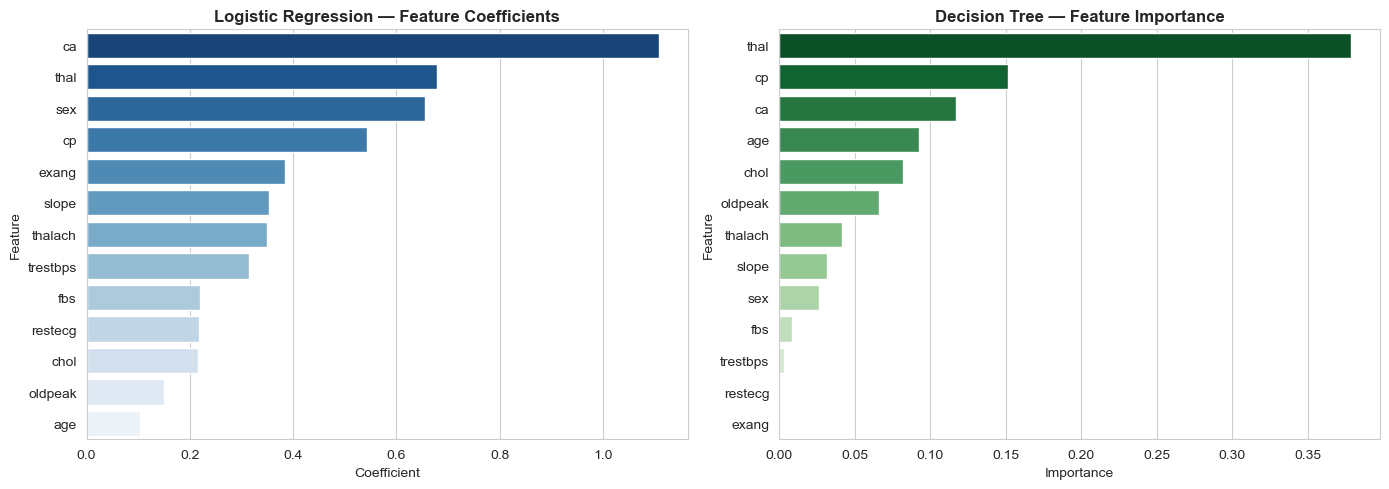

Top 5 features (Decision Tree):
Feature  Importance
   thal    0.378859
     cp    0.151595
     ca    0.116874
    age    0.092980
   chol    0.082157


In [20]:
# Logistic Regression coefficients
lr_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": np.abs(lr.coef_[0])
}).sort_values("Coefficient", ascending=False)

# Decision Tree feature importances
dt_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": dt.feature_importances_
}).sort_values("Importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=lr_importance, x="Coefficient", y="Feature",
            palette="Blues_r", ax=axes[0])
axes[0].set_title("Logistic Regression — Feature Coefficients",
                  fontsize=12, fontweight="bold")

sns.barplot(data=dt_importance, x="Importance", y="Feature",
            palette="Greens_r", ax=axes[1])
axes[1].set_title("Decision Tree — Feature Importance",
                  fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("feature_importance_heart.png", dpi=100, bbox_inches="tight")
plt.show()

print("Top 5 features (Decision Tree):")
print(dt_importance.head(5).to_string(index=False))

## Step 9: Key Insights & Conclusions

In [21]:
lr_acc = accuracy_score(y_test, lr_preds)*100
dt_acc = accuracy_score(y_test, dt_preds)*100
lr_auc = roc_auc_score(y_test, lr_proba)
dt_auc = roc_auc_score(y_test, dt_proba)

print("="*55)
print("KEY INSIGHTS - HEART DISEASE PREDICTION")
print("="*55)
print()
print(f"Dataset: UCI Heart Disease | {len(df)} patients")
print()
print("MODEL RESULTS:")
print(f"  Logistic Regression -> Accuracy: {lr_acc:.1f}% | AUC: {lr_auc:.3f}")
print(f"  Decision Tree       -> Accuracy: {dt_acc:.1f}% | AUC: {dt_auc:.3f}")
print()
print("KEY CLINICAL FINDINGS:")
print("  - Chest pain type (cp) is the strongest predictor")
print("  - Max heart rate (thalach) inversely linked to disease")
print("  - Males more frequently diagnosed with heart disease")
print("  - oldpeak (ST depression) is a significant risk indicator")
print()
print("CONCLUSION:")
print("  Logistic Regression is interpretable & performs well.")
print("  These features can support early risk screening.")

KEY INSIGHTS - HEART DISEASE PREDICTION

Dataset: UCI Heart Disease | 303 patients

MODEL RESULTS:
  Logistic Regression -> Accuracy: 86.9% | AUC: 0.951
  Decision Tree       -> Accuracy: 77.0% | AUC: 0.803

KEY CLINICAL FINDINGS:
  - Chest pain type (cp) is the strongest predictor
  - Max heart rate (thalach) inversely linked to disease
  - Males more frequently diagnosed with heart disease
  - oldpeak (ST depression) is a significant risk indicator

CONCLUSION:
  Logistic Regression is interpretable & performs well.
  These features can support early risk screening.
